# Phase 2: Segmentation via Clustering

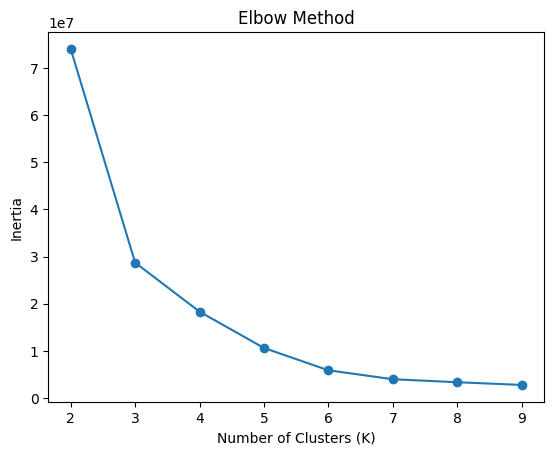

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_selected)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_selected)
    score = silhouette_score(X_selected, labels)
    print(f"K={k}, Silhouette Score={score}")

K=2, Silhouette Score=0.8933135648270141
K=3, Silhouette Score=0.9017856662159304
K=4, Silhouette Score=0.9043759470148686
K=5, Silhouette Score=0.8967174812506125
K=6, Silhouette Score=0.9042326479735897
K=7, Silhouette Score=0.9065625520790065
K=8, Silhouette Score=0.8979749480498258
K=9, Silhouette Score=0.888392699333047


Berdasarkan grafik pada metode Elbow, penurunan inertia yang signifikan terjadi hingga K=4, setelah itu penurunannya menjadi semakin kecil (melandai).
Meskipun nilai silhouette tertinggi diperoleh pada K=7, perbedaannya relatif kecil dibandingkan dengan K=4.
Oleh karena itu, K=4 dipilih sebagai jumlah cluster optimal karena mampu menyeimbangkan kualitas cluster, kemudahan interpretasi, serta validitas struktur data.

In [ ]:
from sklearn.cluster import KMeans

K = 4
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_selected)

df_cluster = X_selected.copy()
df_cluster['cluster'] = clusters

raw_data['cluster'] = clusters

In [ ]:
cluster_profile = df_cluster.groupby('cluster').mean()
cluster_profile

,duration_bin_very_long,poutcome_success,pdays,month,contact_unknown,housing,previous,duration_bin_medium,marital_married,education,day,marital_single,campaign,balance_bin_very_high,job_management
cluster,,,,,,,,,,,,,,,
0,0.247990,0.001956,0.304379,6.203875,0.347100,0.539853,0.031813,0.250616,0.607794,2.049770,0.009275,0.276747,0.456314,0.240003,0.207574
1,0.265772,0.285075,148.331685,6.933616,0.004944,0.453625,3.233522,0.258004,0.585923,2.190913,-0.049526,0.306497,-0.010593,0.379473,0.252119
2,0.239287,0.057808,322.490078,4.473972,0.004314,0.855335,3.077941,0.230371,0.563992,2.007765,-0.228690,0.314927,0.089301,0.193845,0.168248
3,0.270115,0.149425,573.718391,7.568966,0.189655,0.494253,3.517241,0.212644,0.494253,2.235632,-0.079134,0.385057,-0.140805,0.321839,0.327586


## Cluster 0 — “New / Cold Customers”

Segment ini mengindikasikan adanya campaign massal dengan tingkat efektivitas yang relatif rendah. Rendahnya histori interaksi menunjukkan bahwa segmen ini masih berada pada tahap awal hubungan dengan bank dan belum memiliki keterlibatan yang kuat terhadap campaign sebelumnya.

## Cluster 1 — “Loan-Oriented Active Customers”

Segmen ini memiliki nilai tinggi pada fitur housing dan job_blue-collar, yang menunjukkan segmen nasabah dengan kepemilikan housing loan dan karakteristik pekerjaan tertentu. Pola ini mengindikasikan bahwa nasabah pada cluster ini cenderung memiliki kondisi finansial yang lebih fokus pada kebutuhan pembiayaan dibandingkan produk finansial bernilai tinggi.

## Cluster 2 — “High-Value Successful Customers”

Segmen ini merepresentasikan nasabah bernilai tinggi dengan histori keberhasilan campaign yang baik. Tingginya saldo serta keberhasilan interaksi sebelumnya menunjukkan bahwa cluster ini berpotensi menjadi target utama untuk campaign produk premium atau investasi.

## Cluster 3 — “Highly Engaged Long-Term Customers”

Segmen ini menunjukkan tingkat keterlibatan yang tinggi, ditandai dengan frekuensi kontak dan durasi interaksi yang relatif besar. Namun, intensitas interaksi yang tinggi juga berpotensi menyebabkan kejenuhan atau penurunan efektivitas campaign apabila tidak diimbangi dengan pendekatan yang lebih personal.

Heatmap menunjukkan perbedaan karakteristik antar cluster setelah dilakukan standardisasi fitur. Warna merah menunjukkan nilai fitur yang relatif lebih tinggi dibanding rata-rata dataset, sedangkan warna biru menunjukkan nilai yang lebih rendah.

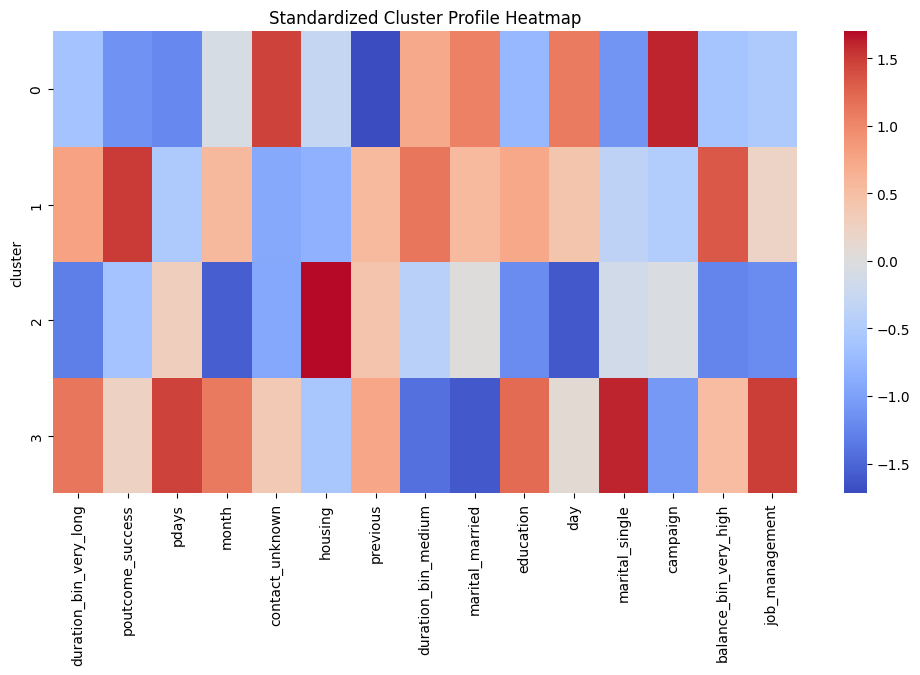

In [ ]:
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

scaler = StandardScaler()
scaled_profile = scaler.fit_transform(cluster_profile)

scaled_profile_df = pd.DataFrame(
    scaled_profile,
    index=cluster_profile.index,
    columns=cluster_profile.columns
)

plt.figure(figsize=(12,6))
sns.heatmap(scaled_profile_df, cmap='coolwarm', center=0)
plt.title("Standardized Cluster Profile Heatmap")
plt.show()

**Cluster 0** didominasi oleh poutcome_unknown dan contact_unknown, yang mengindikasikan rendahnya histori interaksi nasabah.<br>
**Cluster 1** memiliki nilai tinggi pada fitur housing dan job_blue-collar, yang menunjukkan segmen nasabah dengan karakteristik pekerjaan tertentu serta kepemilikan housing loan yang relatif tinggi.<br>
**Cluster 2** menonjol pada poutcome_success, balance_bin_very_high, dan job_retired, yang mengindikasikan segmen nasabah bernilai tinggi dengan tingkat keberhasilan campaign yang baik.<br>
**Cluster 3** memiliki nilai tinggi pada pdays, month, dan duration_bin_very_long, yang menunjukkan intensitas interaksi yang lebih tinggi dibanding cluster lainnya.

In [ ]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)
db_labels = dbscan.fit_predict(X_selected)

df_cluster['dbscan_cluster'] = db_labels

# cek jumlah cluster & noise
import numpy as np
print("Cluster DBSCAN:", set(db_labels))
print("Jumlah noise (-1):", np.sum(db_labels == -1))

Cluster DBSCAN: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66), np.int64(67), np.int64(68), np.int64(69), np.int64(70),

DBSCAN menghasilkan jumlah cluster yang sangat banyak serta proporsi noise yang tinggi (~40% dari data), yang menunjukkan bahwa algoritma ini kurang cocok untuk struktur dataset ini.<br>
Hal ini kemungkinan disebabkan oleh distribusi data yang tidak memiliki kepadatan (density) yang jelas, sehingga DBSCAN kesulitan membentuk cluster yang stabil dan menghasilkan banyak noise.

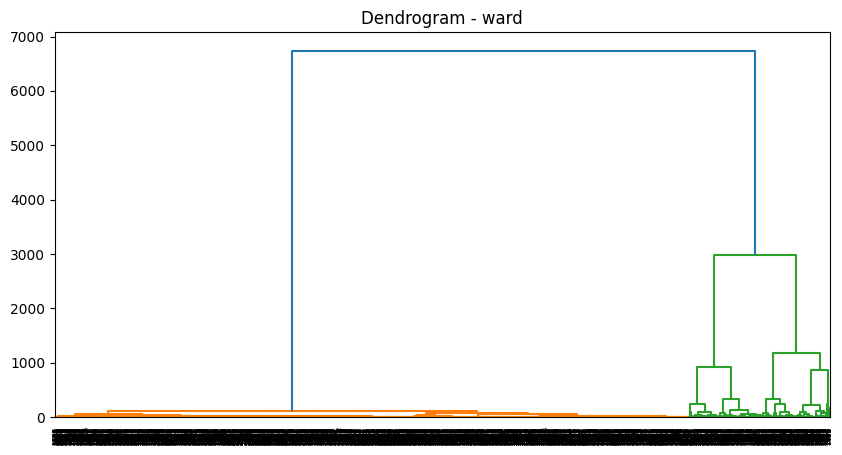

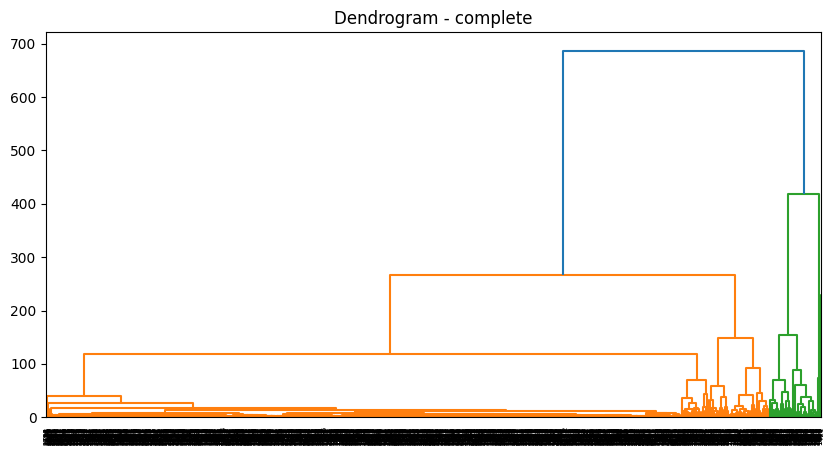

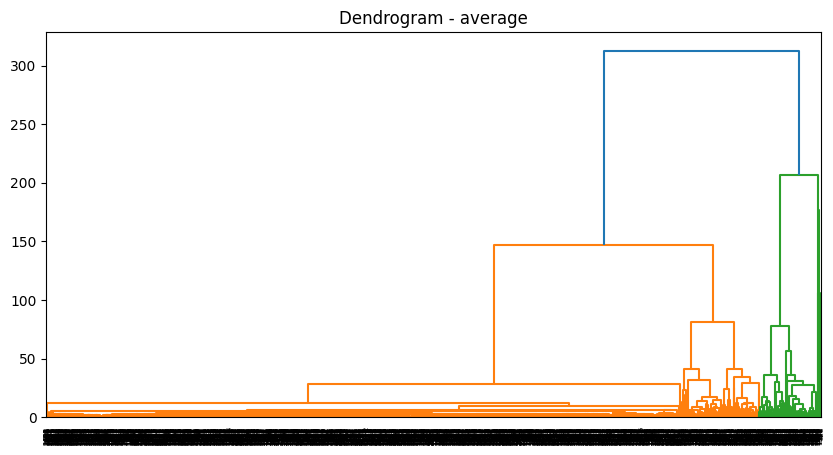

In [ ]:
sample = X_selected.sample(3000, random_state=42)

from scipy.cluster.hierarchy import dendrogram, linkage

methods = ['ward', 'complete', 'average']

for method in methods:
    linked = linkage(sample, method=method)

    plt.figure(figsize=(10,5))
    dendrogram(linked)
    plt.title(f"Dendrogram - {method}")
    plt.show()

Karena hierarchical clustering memiliki kompleksitas komputasi yang tinggi terhadap jumlah data, penggunaan seluruh dataset (~45.000 data) menyebabkan keterbatasan memori pada runtime. Oleh karena itu, digunakan sampel representatif sebanyak 3000 data untuk membangun dendrogram dengan tetap mempertahankan pola utama dataset.

##Ward Linkage
Dendrogram pada metode Ward menunjukkan adanya pemisahan cluster yang paling jelas dengan lonjakan jarak yang besar pada tahap akhir penggabungan cluster. Hal ini mengindikasikan bahwa data memiliki struktur segmentasi yang cukup kuat dan sejalan dengan hasil K-Means yang sebelumnya menunjukkan K=4 sebagai jumlah cluster optimal. Dibandingkan metode lainnya, Ward linkage menghasilkan cluster yang paling stabil dan mudah diinterpretasikan.

##Complete Linkage
Metode complete linkage menghasilkan proses penggabungan cluster yang lebih bertahap dengan beberapa pemisahan yang cukup jelas. Namun, metode ini terlihat lebih sensitif terhadap outlier sehingga beberapa cluster menjadi terlalu spesifik dan kurang seimbang dibandingkan Ward linkage.

##Average Linkage
Average linkage menunjukkan proses penggabungan cluster yang lebih halus dengan jarak antar cluster yang relatif lebih kecil. Meskipun mampu menunjukkan hubungan umum antar data, batas antar cluster terlihat kurang tegas sehingga hasil segmentasi menjadi kurang kuat untuk interpretasi bisnis dibandingkan metode Ward.

## Kesimpulan

K-Means menghasilkan cluster yang jelas, seimbang, dan mudah diinterpretasikan, sehingga cocok digunakan untuk segmentasi utama.

DBSCAN menghasilkan jumlah cluster yang sangat banyak serta proporsi noise yang tinggi, yang menunjukkan bahwa algoritma ini kurang sesuai untuk dataset ini karena distribusi data yang tidak memiliki kepadatan yang jelas.

Hierarchical clustering melalui perbandingan beberapa linkage method menunjukkan bahwa metode Ward menghasilkan struktur cluster yang paling jelas dan stabil dibandingkan complete dan average linkage. Hasil ini juga konsisten dengan K-Means dalam menunjukkan adanya pemisahan cluster yang cukup kuat pada data.

Secara keseluruhan, **K-Means** dipilih sebagai metode utama untuk segmentasi karena menghasilkan cluster yang stabil, terstruktur, dan mudah diinterpretasikan, sementara DBSCAN dan Hierarchical clustering digunakan sebagai metode pendukung untuk memahami struktur data dan mendeteksi potensi outlier.